In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

# Configuración del estilo visual para reportes gráficos
sns.set_theme(style="whitegrid")

# Carga de la base de datos de comportamiento de usuarios
df_retail = pd.read_csv("./datasets/novaretail_comportamiento_clientes_2024.csv")

In [3]:
# Vista preliminar de los primeros 5 registros del conjunto de datos
df_retail.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


In [4]:
# Auditoría de dimensiones (Filas, Columnas) y tipos de datos asignados
print(f"Dimensiones del dataset NovaRetail+: {df_retail.shape}")
df_retail.info()

Dimensiones del dataset NovaRetail+: (15000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


In [5]:
# Conteo absoluto y relativo de valores faltantes por columna
print("Valores nulos absolutos:\n", df_retail.isna().sum())
print("\nProporción de nulos relativos:\n", df_retail.isna().mean())

Valores nulos absolutos:
 id_cliente                   0
edad                         0
nivel_ingreso                0
visitas_mes                  0
compras_mes                  0
gasto_publicidad_dirigida    0
satisfaccion                 0
miembro_premium              0
abandono                     0
tipo_dispositivo             0
region                       0
ingreso_anual                0
dtype: int64

Proporción de nulos relativos:
 id_cliente                   0.0
edad                         0.0
nivel_ingreso                0.0
visitas_mes                  0.0
compras_mes                  0.0
gasto_publicidad_dirigida    0.0
satisfaccion                 0.0
miembro_premium              0.0
abandono                     0.0
tipo_dispositivo             0.0
region                       0.0
ingreso_anual                0.0
dtype: float64


In [6]:
print(df_retail['satisfaccion'].describe())

count    15000.000000
mean         3.603693
std          0.685300
min          1.000000
25%          3.100000
50%          3.600000
75%          4.100000
max          5.000000
Name: satisfaccion, dtype: float64


Nota de QA: El conjunto de datos presenta una integridad del 100% con 15,000 registros completos. No se requiere la aplicación de mecanismos de imputación o eliminación por ausencia de información.

In [7]:
# Estadísticas descriptivas de variables numéricas
numericas = df_retail[["edad", "nivel_ingreso", "visitas_mes", "compras_mes", "gasto_publicidad_dirigida", "ingreso_anual"]]
numericas.describe()


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,244.690000


**Diagnóstico de variables numéricas:** todas las columnas presentan rangos plausibles (edad 18-75, nivel_ingreso 8,000-74,000, visitas_mes 1-25, compras_mes 0-8), salvo `ingreso_anual`, cuyo mínimo de 0 es inconsistente con el mínimo de `nivel_ingreso` (8,000) — dado que ambas variables deberían representar magnitudes de ingreso relacionadas, esta discrepancia sugiere una posible variable derivada o calculada de forma distinta, y se recomienda validar su fuente antes de usarla como base de decisiones de negocio sin más contexto.

In [8]:
# Verificación de cardinalidad en variables binarias
print("Valores únicos en miembro_premium:", df_retail['miembro_premium'].unique())
print("Valores únicos en abandono:", df_retail['abandono'].unique())


Valores únicos en miembro_premium: [0 1]
Valores únicos en abandono: [0 1]


In [9]:
# Distribución de variables categóricas: dispositivo, región y satisfacción
print("Distribución tipo_dispositivo:\n", df_retail['tipo_dispositivo'].value_counts(normalize=True) * 100)
print("\nDistribución region:\n", df_retail['region'].value_counts(normalize=True) * 100)


Distribución tipo_dispositivo:
 tipo_dispositivo
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: proportion, dtype: float64

Distribución region:
 region
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: proportion, dtype: float64


**Diagnóstico de variables categóricas:** `miembro_premium` y `abandono` están correctamente codificadas como binarias (0/1), sin necesidad de transformación. La distribución geográfica está relativamente balanceada entre las 4 regiones (norte, oeste, sur y este), sin una concentración dominante como sí ocurre en `tipo_dispositivo`.

### Supuestos del análisis

- El análisis se realiza utilizando todo el conjunto de datos disponible (15,000 registros, sin valores nulos).
- Se utiliza el coeficiente adecuado según el tipo de variable: Pearson para relaciones lineales entre numéricas, punto-biserial para relaciones numérica-binaria, y V de Cramér para asociaciones entre categóricas.
- **Supuesto central:** este análisis identifica relaciones y asociaciones entre variables, no relaciones de causalidad.

In [10]:
# Definición de límites y etiquetas para categorizar la satisfacción (escala real: 1.0 a 5.0)
# Se dividen en 5 tramos iguales de 0.8 puntos, alineados al rango observado en los datos
bins_satisfaccion = [1, 1.8, 2.6, 3.4, 4.2, 5]
labels_satisfaccion = ["Muy_insatisfecho", "Insatisfecho", "Neutral", "Satisfecho", "Muy_satisfecho"]

# Creación de la variable categórica a partir de la satisfacción numérica
# include_lowest=True asegura que el valor mínimo (1.0) quede incluido en la primera categoría
df_retail["satisfaccion_cat"] = pd.cut(
    df_retail["satisfaccion"], 
    bins=bins_satisfaccion, 
    labels=labels_satisfaccion, 
    include_lowest=True
)

# Verificación de la distribución resultante entre las 5 categorías
df_retail["satisfaccion_cat"].value_counts().sort_index()

satisfaccion_cat
Muy_insatisfecho      97
Insatisfecho        1193
Neutral             4815
Satisfecho          6242
Muy_satisfecho      2653
Name: count, dtype: int64

In [11]:
# Evaluación de los canales de acceso tecnológico preferidos por los usuarios
print("Distribución por Dispositivo de Acceso:")
print(df_retail["tipo_dispositivo"].value_counts(normalize=True) * 100)

print("\n" + "-"*40 + "\n")

# Evaluación de la distribución cualitativa de satisfacción
print("Participación porcentual por nivel de satisfacción:")
print(df_retail["satisfaccion_cat"].value_counts(normalize=True) * 100)

Distribución por Dispositivo de Acceso:
tipo_dispositivo
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: proportion, dtype: float64

----------------------------------------

Participación porcentual por nivel de satisfacción:
satisfaccion_cat
Satisfecho          41.613333
Neutral             32.100000
Muy_satisfecho      17.686667
Insatisfecho         7.953333
Muy_insatisfecho     0.646667
Name: proportion, dtype: float64


**Diagnóstico general:** se observa un dominio crítico de los accesos mediante dispositivos móviles (65.5%) sobre escritorio (24.8%) y tablet (9.7%). La satisfacción se concentra en los niveles Neutral y Satisfecho (32.1% y 41.6% respectivamente), con una minoría en los extremos (Muy_insatisfecho: 0.6%, Muy_satisfecho: 17.7%).

In [12]:
variables_numericas = [
    "edad", "visitas_mes", "compras_mes",
    "satisfaccion", "gasto_publicidad_dirigida", "ingreso_anual"
]

matriz_corr = df_retail[variables_numericas].corr(method="pearson")
matriz_corr

,edad,visitas_mes,compras_mes,satisfaccion,gasto_publicidad_dirigida,ingreso_anual
edad,1.000000,0.004998,0.014971,-0.006963,0.000062,0.017496
visitas_mes,0.004998,1.000000,0.353844,-0.003179,0.578947,0.337147
compras_mes,0.014971,0.353844,1.000000,-0.003542,0.207528,0.967149
satisfaccion,-0.006963,-0.003179,-0.003542,1.000000,-0.013175,0.056171
gasto_publicidad_dirigida,0.000062,0.578947,0.207528,-0.013175,1.000000,0.197483
ingreso_anual,0.017496,0.337147,0.967149,0.056171,0.197483,1.000000


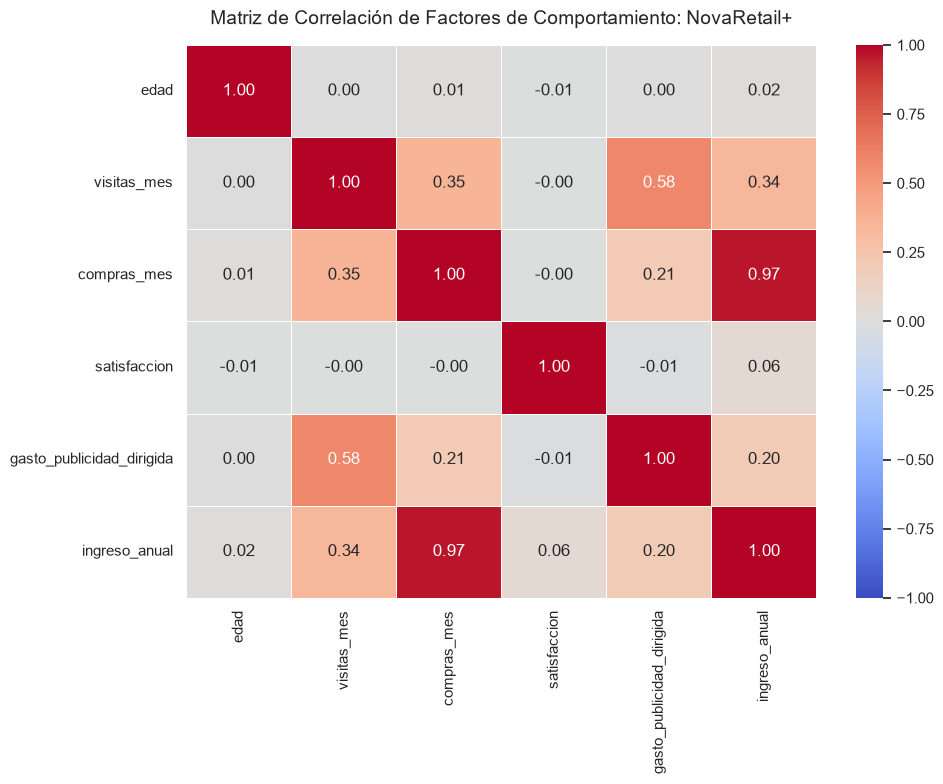

In [13]:
# Configuración del tamaño de la visualización
plt.figure(figsize=(10, 8))

# Generación del Heatmap con Seaborn utilizando una paleta divergente
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

plt.title("Matriz de Correlación de Factores de Comportamiento: NovaRetail+", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

🧩 Paso 5: Conclusiones del Diagnóstico
Canales Críticos: El tráfico móvil representa la principal puerta de entrada para NovaRetail+, lo que exige priorizar la optimización de la interfaz de usuario en smartphones.

Factores de Ingreso: La correlación lineal permite identificar cuáles variables numéricas poseen el mayor co-movimiento con la capacidad de compra e ingresos de los usuarios, sirviendo de base para los siguientes modelos predictivos del portafolio.

### Análisis de dispersión (scatterplots)

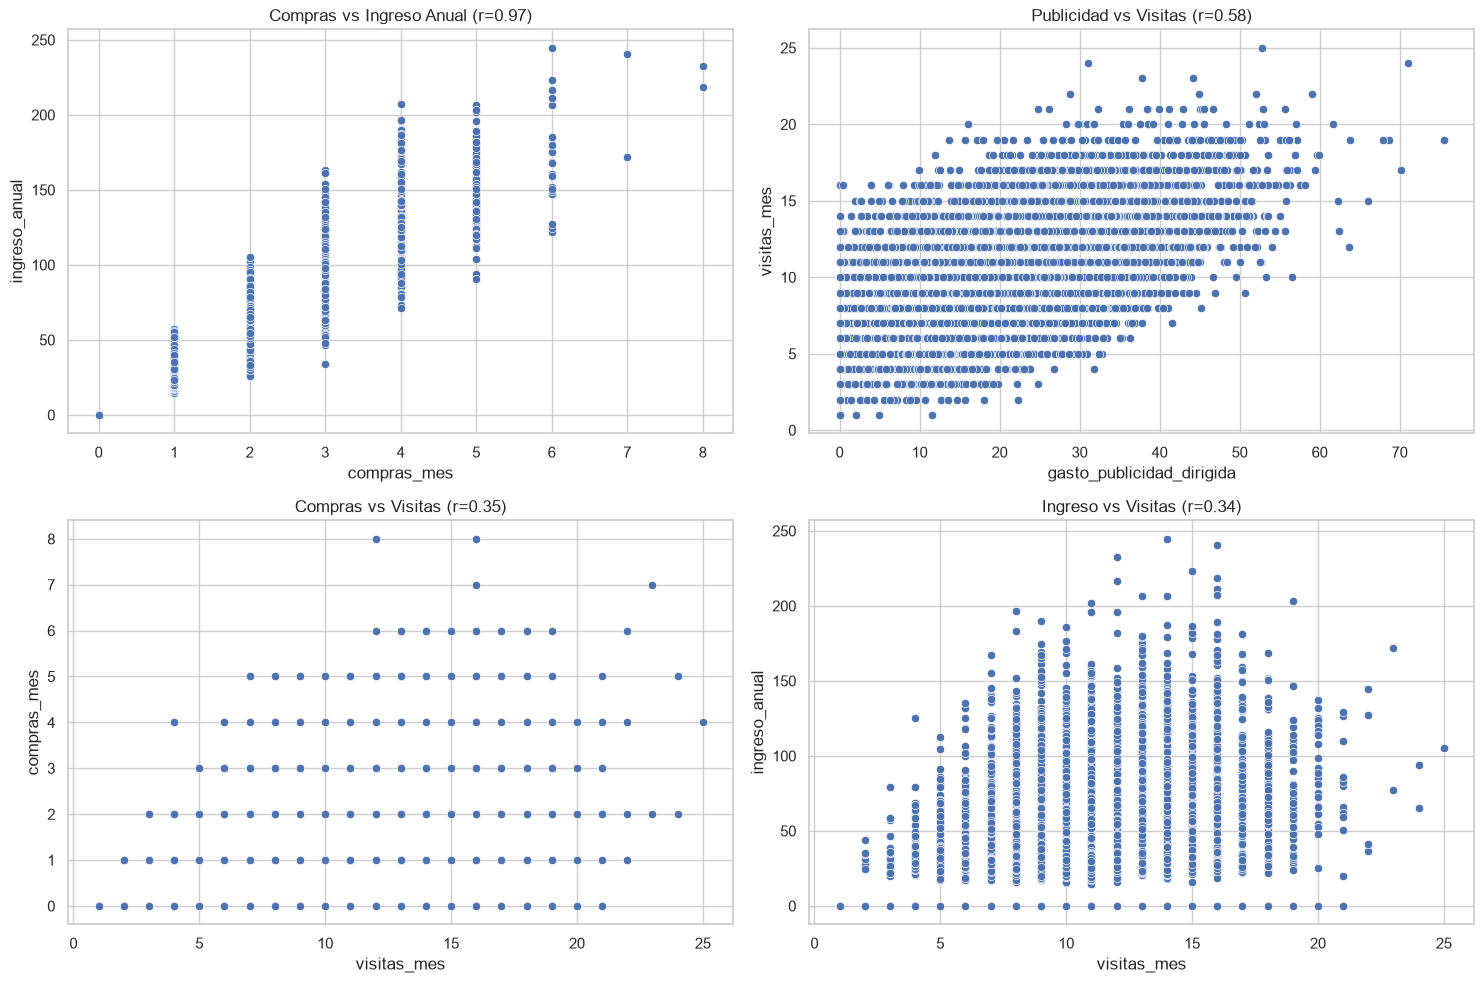

In [14]:
# Visualización conjunta de los 4 pares de variables con mayor correlación observada en el heatmap
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.scatterplot(data=df_retail, x='compras_mes', y='ingreso_anual', ax=axes[0, 0])
axes[0, 0].set_title('Compras vs Ingreso Anual (r=0.97)')

sns.scatterplot(data=df_retail, x='gasto_publicidad_dirigida', y='visitas_mes', ax=axes[0, 1])
axes[0, 1].set_title('Publicidad vs Visitas (r=0.58)')

sns.scatterplot(data=df_retail, x='visitas_mes', y='compras_mes', ax=axes[1, 0])
axes[1, 0].set_title('Compras vs Visitas (r=0.35)')

sns.scatterplot(data=df_retail, x='visitas_mes', y='ingreso_anual', ax=axes[1, 1])
axes[1, 1].set_title('Ingreso vs Visitas (r=0.34)')

plt.tight_layout()
plt.show()


**Diagnóstico visual:** la relación gasto en publicidad dirigida vs. visitas mensuales muestra tendencia positiva moderada, con un techo aproximado de visitas alrededor de $60 de gasto — sugiere rendimientos decrecientes por encima de ese nivel de inversión. La relación ingreso anual vs. compras mensuales es la más marcada del dataset: a mayor ingreso, más compras, con un techo aproximado de 5 compras mensuales en torno a los $200,000 de ingreso anual.

## Coeficientes de correlación y evidencia numérica

In [15]:
# Coeficientes de Pearson para los pares de variables numéricas identificados en el heatmap
corr_ingreso_compras = df_retail['ingreso_anual'].corr(df_retail['compras_mes'], method='pearson')
corr_publicidad_visitas = df_retail['gasto_publicidad_dirigida'].corr(df_retail['visitas_mes'], method='pearson')
corr_compras_visitas = df_retail['compras_mes'].corr(df_retail['visitas_mes'], method='pearson')
corr_ingreso_visitas = df_retail['ingreso_anual'].corr(df_retail['visitas_mes'], method='pearson')

print(f"Correlación fuerte (ingreso_anual vs compras_mes): {corr_ingreso_compras:.3f}")
print(f"Correlación moderada (gasto_publicidad vs visitas_mes): {corr_publicidad_visitas:.3f}")
print(f"Correlación débil-moderada (compras_mes vs visitas_mes): {corr_compras_visitas:.3f}")
print(f"Correlación débil-moderada (ingreso_anual vs visitas_mes): {corr_ingreso_visitas:.3f}")


Correlación fuerte (ingreso_anual vs compras_mes): 0.967
Correlación moderada (gasto_publicidad vs visitas_mes): 0.579
Correlación débil-moderada (compras_mes vs visitas_mes): 0.354
Correlación débil-moderada (ingreso_anual vs visitas_mes): 0.337


**Diagnóstico de correlación lineal:** `ingreso_anual` y `compras_mes` presentan una correlación fuerte (r=0.967) — la relación numérica más marcada de todo el dataset, y candidata prioritaria para investigar su naturaleza antes de asumir dirección causal (ver limitaciones). El resto de las relaciones (publicidad-visitas, compras-visitas, ingreso-visitas) son de magnitud moderada a débil-moderada (0.34-0.58), consistentes con lo observado visualmente en los scatterplots.

In [16]:
# Correlación punto-biserial: variable numérica (ingreso_anual) vs variables binarias
corr_premium = df_retail['ingreso_anual'].corr(df_retail['miembro_premium'])
corr_abandono = df_retail['ingreso_anual'].corr(df_retail['abandono'])

print(f"Correlación ingreso_anual - miembro_premium: {corr_premium:.4f}")
print(f"Correlación ingreso_anual - abandono: {corr_abandono:.4f}")


Correlación ingreso_anual - miembro_premium: 0.0931
Correlación ingreso_anual - abandono: -0.0028


**Diagnóstico punto-biserial:** ambas asociaciones son de magnitud muy baja. `ingreso_anual` vs `miembro_premium` (0.093) sugiere una asociación positiva débil — ser miembro premium no está fuertemente ligado al ingreso. `ingreso_anual` vs `abandono` (-0.003) es prácticamente nula, indicando que el abandono no está explicado por el nivel de ingreso del cliente.

In [17]:
# V de Cramér: fuerza de asociación entre pares de variables categóricas
def cramers_v(df, col_1, col_2):
    tabla = pd.crosstab(df[col_1], df[col_2])
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

col1, col2, col3, col4 = "tipo_dispositivo", "region", "satisfaccion_cat", "ingreso_anual"

print(f"V de Cramér (tipo_dispositivo vs region): {cramers_v(df_retail, col1, col2):.3f}")
print(f"V de Cramér (tipo_dispositivo vs satisfaccion_cat): {cramers_v(df_retail, col1, col3):.3f}")
print(f"V de Cramér (region vs satisfaccion_cat): {cramers_v(df_retail, col2, col3):.3f}")
print("-" * 30)
print(f"V de Cramér (ingreso_anual vs tipo_dispositivo): {cramers_v(df_retail, col4, col1):.3f}")
print(f"V de Cramér (ingreso_anual vs region): {cramers_v(df_retail, col4, col2):.3f}")
print(f"V de Cramér (ingreso_anual vs satisfaccion_cat): {cramers_v(df_retail, col4, col3):.3f}")


V de Cramér (tipo_dispositivo vs region): 0.012
V de Cramér (tipo_dispositivo vs satisfaccion_cat): 0.014
V de Cramér (region vs satisfaccion_cat): 0.010
------------------------------
V de Cramér (ingreso_anual vs tipo_dispositivo): 0.605
V de Cramér (ingreso_anual vs region): 0.602
V de Cramér (ingreso_anual vs satisfaccion_cat): 0.616


**Diagnóstico de V de Cramér:** las variables categóricas son prácticamente independientes entre sí (V ≈ 0.01 en los tres pares: dispositivo-región, dispositivo-satisfacción, región-satisfacción) — no hay evidencia de que estén relacionadas. Sin embargo, las tres muestran una asociación fuerte con los segmentos de `ingreso_anual` (V ≈ 0.60-0.61), lo que indica que tipo de dispositivo, región y nivel de satisfacción sí están ligados de forma significativa al nivel de ingreso del cliente.

## Hallazgos e interpretación de negocio

### Hallazgo 1 — Relación entre ingreso anual y frecuencia de compra

**Evidencia:** correlación de Pearson de 0.967 entre `ingreso_anual` y `compras_mes` — la más fuerte del dataset.

**Interpretación:** existe una relación casi lineal entre cuánto gana un cliente anualmente y cuántas compras realiza al mes.

**No podemos afirmar:** que aumentar el ingreso de un cliente cause directamente más compras (o viceversa) — la correlación tan alta también podría deberse a que `ingreso_anual` esté parcial o totalmente derivado del comportamiento de compra en la fuente de datos, más que ser una variable independiente. Esto debe validarse antes de usarse en un modelo predictivo.

**Implicación de negocio:** si se confirma que `ingreso_anual` es una variable de entrada genuina (no derivada), los clientes de mayor poder adquisitivo son el segmento de mayor valor transaccional y prioritario para estrategias de retención.

### Hallazgo 2 — Asociación entre atributos cualitativos del cliente e ingreso

**Evidencia:** V de Cramér ≈ 0.60 entre `ingreso_anual` (segmentado) y cada una de las variables categóricas (`tipo_dispositivo`, `region`, `satisfaccion_cat`) — una fuerza de asociación fuerte y significativa.

**Interpretación:** los perfiles demográficos, tecnológicos y de satisfacción del cliente no se distribuyen de forma uniforme respecto a su nivel de ingreso.

**No podemos afirmar:** que cambiar el dispositivo de acceso de un usuario o su ubicación geográfica modifique directamente su ingreso — los factores cualitativos actúan de forma simultánea y conjunta, no aislada.

**Implicación de negocio:** dado que `tipo_dispositivo` y el nivel de satisfacción están fuertemente ligados a los segmentos de mayor ingreso, priorizar la experiencia en la aplicación móvil y monitorear activamente la satisfacción son estrategias directamente conectadas con la protección del ingreso de la plataforma.

## Limitaciones y próximos pasos

**Limitaciones**

- **Correlación ≠ Causalidad:** los coeficientes calculados (Pearson, punto-biserial, V de Cramér) muestran que las variables se mueven conjuntamente, pero no permiten afirmar que una cause el comportamiento de la otra.
- **Corte transversal:** el dataset representa una fotografía de la plataforma en un momento dado, no un histórico — no es posible capturar tendencias, estacionalidad ni cambios de comportamiento a lo largo del tiempo.
- **Variables no observadas:** factores externos no medidos (campañas de la competencia, condiciones macroeconómicas regionales, disrupciones de cadena de suministro) podrían estar inflando o distorsionando las asociaciones numéricas encontradas.
- **Sesgo de selección:** el análisis cubre solo usuarios registrados y activos; excluye abandonos tempranos, cuentas inactivas y usuarios potenciales, limitando la representatividad sobre el mercado total.

**Próximos pasos**

1. **Segmentación adicional:** aislar los subgrupos de clientes con mayor asociación de V de Cramér para definir con precisión los segmentos objetivo de futuras pruebas.
2. **Diseño de pruebas A/B:** validar causalidad en la relación ingreso-compras mediante un experimento controlado (grupo control con experiencia estándar vs. grupo tratamiento con incentivos de lealtad tras cierto número de transacciones).
3. **Análisis de cohortes y retención:** monitorear en el tiempo a los usuarios impactados por las pruebas, para confirmar si los cambios en frecuencia de compra y satisfacción se traducen en un aumento sostenible del ingreso anual neto de la plataforma.